# Deep Learning Assignment 1 Training Notebook Part 2
---
###### Author : Joel Quadras (D22125093)
###### Part 2: Transfer Learning

## Data preprocessing

### Import Libararies and Mount Google Drive




In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Aug 29 12:27:56 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 54.8 gigabytes of available RAM

You are using a high-RAM runtime!


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import gdown
import os,glob
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import ast
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Concatenate, Dense, LSTM, Input,GRU, concatenate,Dropout,LeakyReLU,SimpleRNN,Reshape
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Input,Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import one_hot
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import Flatten
from keras.models import Model
import joblib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from tensorflow.keras.layers import LSTM, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential
from keras.layers import Conv1D, GlobalMaxPooling1D

In [ ]:
#checking weather GPU avaliable or not
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
data_url = "https://drive.google.com/drive/folders/1mrXxH6cFy3yUFYsXoYHLhNI0QevCvpn4?usp=drive_link"
gdown.download_folder (data_url, quiet=True, use_cookies=False)

KeyboardInterrupt: ignored

### Train Data Preprocessing

In [ ]:
#Loading data
df_full_train = pd.read_csv("/content/original_dataset/train.csv")

FileNotFoundError: ignored

In [ ]:
df_full_train.head()

In [ ]:
### Test Data Preprocessing

In [ ]:
# Loading the separate test dataset
df_full_test = pd.read_csv("/content/original_dataset/test.csv")

In [ ]:
df_full_test.head()

In [ ]:
# Combine the train and test datasets along the rows (axis=0)
combined_df = pd.concat([df_full_train, df_full_test], axis=0, ignore_index=True)

# Display the combined dataframe
print(combined_df)

In [ ]:
combined_df.info()

In [ ]:
#we have two columns which are having less sample comapred to the total samples
#i.e: "Song Year" and "Track id" columns

In [ ]:
#checking wether the dataset had null values in the combined dataset

combined_df.isnull().sum()

In [ ]:
#we have some null values is the dataset which are song year, Track_id
#so we are going to drop the columns from combined dataset

In [ ]:
# Droping the specified columns from the combined dataframe
columns_to_drop = ["Song year", "Track_id", "Language"]
combined_df = combined_df.drop(columns=columns_to_drop)

# Display the updated combined dataframe
print(combined_df)

In [ ]:
combined_df.isnull().sum()

In [ ]:
#droping null values samples from the dataset
combined_df = combined_df.dropna()

In [ ]:
# Saving the combined dataset to a CSV file after cleaning the dataset
combined_df.to_csv("/content/drive/MyDrive/Data_Saved/combined_dataset.csv", index=False)

In [ ]:
# Grouping data by Artist and calculate song count
artist_song_count = combined_df.groupby("Artist")["Song"].count().reset_index()


In [ ]:
#Sorting artists by song count in descending order
sorted_artists = artist_song_count.sort_values(by="Song", ascending=False)

In [ ]:
#
top_10_artists = sorted_artists.head(10)

In [ ]:
top_10_artists

In [ ]:
#Creating a new dataset for top 10 artists
top_10_artist_data = combined_df[combined_df["Artist"].isin(top_10_artists["Artist"])]

In [ ]:
# Displaying the new dataset for top 10 artists
print(top_10_artist_data)

In [ ]:
# Saving the combined dataset to a CSV file after cleaning the dataset
top_10_artist_data.to_csv("/content/drive/MyDrive/Data_Saved/top_10_artist_dataset.csv", index=False)

In [ ]:
top_10_artist_data

In [ ]:
top_10_artist_data.isnull().sum()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt


In [ ]:
# Spliting data into train, validation, and no testset in this section
#dividing data into 90% and 10% testset

train_data, val_data = train_test_split(top_10_artist_data, test_size=0.1, random_state=42, stratify =top_10_artist_data["Artist"])


In [ ]:
# Converting artist labels to one-hot encoding as it is a multiclass classification

#Converting first artist labels to integers using label encoding
label_encoder = LabelEncoder()
train_data["Artist"] = label_encoder.fit_transform(train_data["Artist"])
val_data["Artist"] = label_encoder.transform(val_data["Artist"])


In [ ]:
#Total number of classes
num_classes = len(label_encoder.classes_)

In [ ]:
# Creating TF-IDF text vectorizer

#When we run population data we can keep 10000 or more
#For now we are keeping 5000 for model building and computational purpose

max_features = 5000  # we can adjust as needed

tfidf_vectorizer = TfidfVectorizer(max_features=max_features)

In [ ]:
# Fitting and transforming the text data
#training set
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data["Lyrics"])
#validation set
X_val_tfidf = tfidf_vectorizer.transform(val_data["Lyrics"])



In [ ]:
# Converting secondly Artist labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(train_data["Artist"], num_classes)
y_val = tf.keras.utils.to_categorical(val_data["Artist"], num_classes)


In [ ]:
# Converting sparse matrices to dense arrays
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense = X_val_tfidf.toarray()


In [ ]:
#Data saving for further use in future

np.savez('/content/drive/MyDrive/original_dataset/Task_2_model_weights/top_10_artist_train_test.npz',
         X_train=X_train_tfidf_dense,y_train=y_train, X_val = X_val_tfidf_dense, y_val= y_val)

## Models

### Multilayer-LSTM

In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
multi_LSTM_TL_model = load_model('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_model/multi_layer_lstm_model.h5')

# Load the history
# with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_model/multi_layer_lstm_history.pkl', 'rb') as f:
#     multi_layer_lstm_history = pickle.load(f)

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10

print("Printing transfer learning multilayer layer lstm epochs")
multi_layer_lstm_tl_history = multi_LSTM_TL_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing transfer learning multilayer layer lstm epochs
Epoch 1/10
261/261 [==============================] - 111s 410ms/step - loss: 2.3020 - accuracy: 0.1658 - val_loss: 2.2748 - val_accuracy: 0.1735
Epoch 2/10
261/261 [==============================] - 106s 406ms/step - loss: 2.2759 - accuracy: 0.1694 - val_loss: 2.2763 - val_accuracy: 0.1735
Epoch 3/10
261/261 [==============================] - 106s 406ms/step - loss: 2.2753 - accuracy: 0.1706 - val_loss: 2.2766 - val_accuracy: 0.1735


In [ ]:
#Model saving
multi_LSTM_TL_model.save('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_LSTM_TL_model/multi_LSTM_TL_model.h5')


In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_LSTM_TL_model/multi_layer_lstm_tl_history.pkl', 'wb') as f:
    pickle.dump(multi_layer_lstm_tl_history, f)

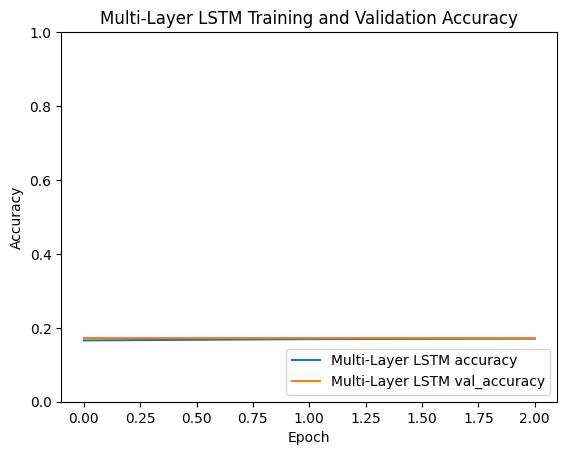

In [ ]:
# Plot training and validation accuracy as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(multi_layer_lstm_tl_history, 'Multi-Layer LSTM')

### CNN

In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
CNN_TL_model = load_model('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_model/cnn_model.h5')

# Load the history
with open('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_model/cnn_history.pkl', 'rb') as f:
    cnn_history = pickle.load(f)

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10

print("Printing transfer learning multilayer layer lstm epochs")
cnn_tl_history = CNN_TL_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


In [ ]:
#Model saving
CNN_TL_model.save('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/CNN_TL_model/CNN_TL_model.h5')


In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/CNN_TL_model/cnn_tl_history.pkl', 'wb') as f:
    pickle.dump(cnn_tl_history, f)

In [ ]:
# Plot training and validation accuracy as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(cnn_tl_history, 'CNN')

### Multilayer LSTM Artist Prediction

In [ ]:
# Building and compile the models

def build_multi_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=False))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())
    return model_lstm

In [ ]:
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion
multi_layer_lstm_artist_model = build_multi_layer_lstm_model()
multi_layer_lstm_artist_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5000, 128)         640000    
                                                                 
 lstm (LSTM)                 (None, 5000, 128)         131584    
                                                                 
 dropout (Dropout)           (None, 5000, 128)         0         
                                                                 
 lstm_1 (LSTM)               (None, 5000, 128)         131584    
                                                                 
 dropout_1 (Dropout)         (None, 5000, 128)         0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10

print("Printing multilayer layer lstm epochs")
multi_layer_lstm_artist_history = multi_layer_lstm_artist_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing multilayer layer lstm epochs
Epoch 1/10
261/261 [==============================] - 113s 411ms/step - loss: 2.3214 - accuracy: 0.1434 - val_loss: 2.2938 - val_accuracy: 0.1735
Epoch 2/10
261/261 [==============================] - 106s 407ms/step - loss: 2.2946 - accuracy: 0.1628 - val_loss: 2.2834 - val_accuracy: 0.1735
Epoch 3/10
261/261 [==============================] - 106s 408ms/step - loss: 2.2841 - accuracy: 0.1659 - val_loss: 2.2800 - val_accuracy: 0.1336
Epoch 4/10
261/261 [==============================] - 106s 408ms/step - loss: 2.2789 - accuracy: 0.1693 - val_loss: 2.2788 - val_accuracy: 0.1735
Epoch 5/10
261/261 [==============================] - 106s 406ms/step - loss: 2.2807 - accuracy: 0.1689 - val_loss: 2.2822 - val_accuracy: 0.1735
Epoch 6/10
261/261 [==============================] - 106s 406ms/step - loss: 2.2760 - accuracy: 0.1697 - val_loss: 2.2690 - val_accuracy: 0.1735
Epoch 7/10
261/261 [==============================] - 106s 405ms/step - loss: 2.2751 -

In [ ]:
#Model saving
multi_layer_lstm_artist_model.save('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_artist_model/multi_layer_lstm_artist_model.h5')


In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_artist_model/multi_layer_lstm_history.pkl', 'wb') as f:
    pickle.dump(multi_layer_lstm_tl_history, f)

Ploting

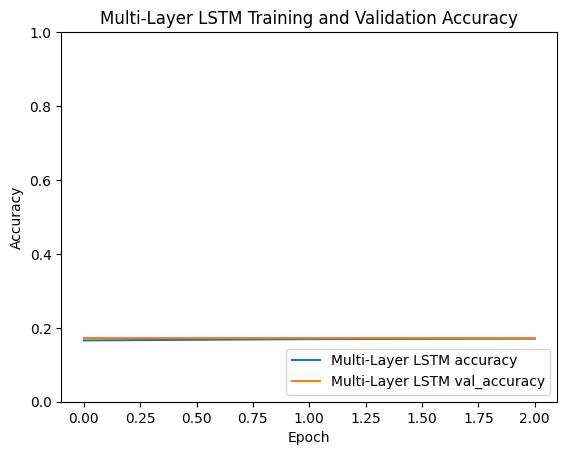

In [ ]:
# Plot training and validation accuracy as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(multi_layer_lstm_tl_history, 'Multi-Layer LSTM')

### CNN Artist Prediction

In [ ]:
# Defining the CNN model here we are using specially Conv1D

def build_cnn_model():
    model_cnn = Sequential()
    model_cnn.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=4, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    model_cnn.add(GlobalMaxPooling1D())
    model_cnn.add(Dense(128, activation='relu'))
    model_cnn.add(Dense(num_classes, activation='softmax'))
    #model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model_cnn

In [ ]:
#with strategy.scope():

cnn_artist_model = build_cnn_model()
cnn_artist_model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])

cnn_artist_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 5000, 128)         640000    
                                                                 
 conv1d (Conv1D)             (None, 4998, 64)          24640     
                                                                 
 conv1d_1 (Conv1D)           (None, 4995, 64)          16448     
                                                                 
 conv1d_2 (Conv1D)           (None, 4991, 64)          20544     
                                                                 
 global_max_pooling1d (Globa  (None, 64)               0         
 lMaxPooling1D)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                      

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# Training the models with dense arrays
# Train the models using distributed training (with larger batch size)
batch_size = 32  # Adjust as needed
epochs = 10  # Adjust as needed
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion

print("Printing CNN Epochs")
cnn_artist_history = cnn_artist_model.fit(X_train_tfidf_dense, y_train, validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing CNN Epochs
Epoch 1/10
261/261 [==============================] - 12s 40ms/step - loss: 2.2714 - accuracy: 0.1729 - val_loss: 2.2746 - val_accuracy: 0.1735
Epoch 2/10
261/261 [==============================] - 10s 39ms/step - loss: 2.2693 - accuracy: 0.1737 - val_loss: 2.2655 - val_accuracy: 0.1735
Epoch 3/10
261/261 [==============================] - 10s 39ms/step - loss: 2.2673 - accuracy: 0.1736 - val_loss: 2.2653 - val_accuracy: 0.1746
Epoch 4/10
261/261 [==============================] - 10s 38ms/step - loss: 2.2663 - accuracy: 0.1741 - val_loss: 2.2645 - val_accuracy: 0.1746
Epoch 5/10
261/261 [==============================] - 10s 38ms/step - loss: 2.2658 - accuracy: 0.1742 - val_loss: 2.2650 - val_accuracy: 0.1746
Epoch 6/10
261/261 [==============================] - 10s 38ms/step - loss: 2.2659 - accuracy: 0.1742 - val_loss: 2.2644 - val_accuracy: 0.1746
Epoch 7/10
261/261 [==============================] - 10s 38ms/step - loss: 2.2655 - accuracy: 0.1742 - val_loss: 2.

In [ ]:
# Save the trained models
cnn_artist_model.save('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_artist_model/cnn_artist_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle
#Saving model history in pickle format
with open('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_artist_model/cnn_artist_history.pkl', 'wb') as f:
    pickle.dump(cnn_tl_history, f)

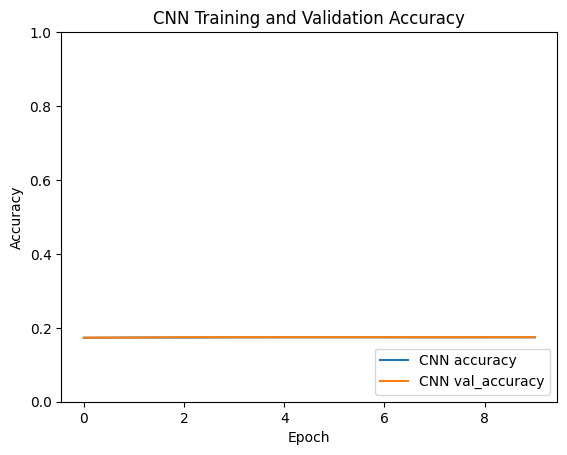

In [ ]:
# Ploting training and validation metrics as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(cnn_artist_history, 'CNN')